<a href="https://colab.research.google.com/github/hirenpatel1404/-Project_5_Basic_Natural_Language_Processing_with_Unsupervised_Learning/blob/main/Project_5__Discover_Topics__in_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hiren patel
##Project 5 — Discover Topics in Text
##Can We Group Documents by Topic?

#Part 1: Load and Explore the Data

In [1]:
#oad the dataset
from sklearn.datasets import fetch_20newsgroups

# Load the training portion of the text dataset.
# Remove headers, footers, and quoted replies to focus on message content.
newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=42
)

# Store the documents separately from their actual category labels.
documents = newsgroups.data
actual_categories = newsgroups.target
category_names = newsgroups.target_names

# The category labels will not be used to train K-Means.
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
#Check the dataset size and categories
# Count the documents and available categories.
print("Number of documents:", len(documents))
print("Number of categories:", len(category_names))

# Display the names of all categories.
print("\nCategory names:")

for name in category_names:
    print(name)

# Count messages that became blank after removing extra text.
blank_count = sum(not document.strip() for document in documents)
print("\nNumber of blank documents:", blank_count)

Number of documents: 11314
Number of categories: 20

Category names:
alt.atheism
comp.graphics
comp.os.ms-windows.misc
comp.sys.ibm.pc.hardware
comp.sys.mac.hardware
comp.windows.x
misc.forsale
rec.autos
rec.motorcycles
rec.sport.baseball
rec.sport.hockey
sci.crypt
sci.electronics
sci.med
sci.space
soc.religion.christian
talk.politics.guns
talk.politics.mideast
talk.politics.misc
talk.religion.misc

Number of blank documents: 300


### Interpretation
I loaded the training portion of the 20 Newsgroups dataset and removed headers, footers, and quoted replies to focus on message content.

The output shows 11,314 documents across 20 categories. These categories cover topics such as computers, vehicles, sports, science, religion, and politics. The category labels describe the known topics, but they will not be used to train K-Means.

There are 300 blank documents after cleaning, leaving 11,014 documents with text. These blank entries contain no useful words for topic analysis, so they should be removed before converting the text into numerical features.

In [3]:
#Display three example documents
# Find documents that contain some text.
nonempty_indices = [
    index
    for index, document in enumerate(documents)
    if document.strip()
]

# Display the first three nonempty examples.
for index in nonempty_indices[:3]:
    print(f"\n--- Document {index} ---")

    # Show the known category only to help explore the dataset.
    category_id = actual_categories[index]
    print("Actual category:", category_names[category_id])

    # Limit the displayed text to keep the output manageable.
    print("\nText:")
    print(documents[index][:1500])
    print()


--- Document 0 ---
Actual category: rec.autos

Text:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


--- Document 1 ---
Actual category: comp.sys.mac.hardware

Text:
A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next t

### Interpretation
I displayed three nonempty documents to examine their content and identify visible topics.
- Document 0 discusses a Bricklin sports car and asks about its engine, production history, and model details. This agrees with its category, rec.autos.
- Document 1 discusses Macintosh hardware upgrades, including clock speed, cooling, and disk functionality. Its content matches comp.sys.mac.hardware.
- Document 2 discusses replacing a Macintosh computer and compares PowerBook models, prices, displays, and storage. It also matches comp.sys.mac.hardware. The displayed text is cut off because the code limits each preview to 1,500 characters.
Documents 1 and 2 share a general computer-hardware topic but discuss different concerns. These examples illustrate how related documents can use some common vocabulary while containing different details. However, three examples do not represent all 20 categories.

###Question:
###Why can’t we simply give the original text to K-Means?
K-Means needs numerical features to calculate distances and cluster centers. Raw text consists of words and sentences, so it must first be converted into numbers. TF-IDF will represent documents using word-based numerical features that K-Means can compare.

#Part 2 — Convert Text into Numbers

In [5]:
import numpy as np

In [6]:
#Remove blank documents
# Keep the positions of documents that contain text.
valid_indices = [
    index
    for index, document in enumerate(documents)
    if document.strip()
]

# Keep only nonempty documents.
clean_documents = [documents[index] for index in valid_indices]

# Keep the matching labels for interpretation only.
clean_categories = np.asarray(actual_categories)[valid_indices]

print("Documents before cleaning:", len(documents))
print("Documents after cleaning:", len(clean_documents))
print("Blank documents removed:", len(documents) - len(clean_documents))

Documents before cleaning: 11314
Documents after cleaning: 11014
Blank documents removed: 300


removed 300 blank documents, reducing the dataset from 11,314 to 11,014 documents. These entries had no remaining text after the earlier cleaning, so they could not provide useful words for topic analysis. The matching category labels were kept separately for later interpretation.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
#Convert the documents into TF-IDF features
# Remove common English words and limit the vocabulary size.
# Keep words that appear in at least two documents.
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    min_df=2
)

# Learn the vocabulary and convert the text into numerical features.
X_tfidf = vectorizer.fit_transform(clean_documents)

print("Number of documents:", X_tfidf.shape[0])
print("Number of features:", X_tfidf.shape[1])
print("TF-IDF matrix shape:", X_tfidf.shape)

Number of documents: 11014
Number of features: 10000
TF-IDF matrix shape: (11014, 10000)


I converted the remaining documents into numerical features using TF-IDF. The resulting matrix has a shape of (11014, 10000): each row represents a document, and each column represents a vocabulary term.

The vocabulary was limited to 10,000 features, with common English stop words removed and terms required to appear in at least two documents. Each TF-IDF value reflects a term’s importance within a document relative to its frequency across the collection. These numerical features can now be used by K-Means.

In [8]:
#Examine some feature names
# Get the words and terms used as features.
feature_names = vectorizer.get_feature_names_out()

# Show a repeatable random sample of 20 features.
rng = np.random.RandomState(42)
sample_features = rng.choice(
    feature_names,
    size=min(20, len(feature_names)),
    replace=False
)

print("Sample feature names:")
print(", ".join(sample_features))

Sample feature names:
nope, impact, brake, incorrect, homosexuals, observer, 600, kids, oct, 389, cy, refugees, labeled, mamma, friday, motors, 610, yellow, primary, sharks


The sample features include words such as “brake,” “motors,” “refugees,” and “sharks,” along with numbers such as “600” and “389.” This shows that the vocabulary contains a mixture of subject-related words, general words, and numerical terms.

These are randomly selected features, not the most important words overall. Their usefulness depends on how they occur across documents.

In [9]:
#Examine important terms in the first document
# Get the TF-IDF scores for the first cleaned document.
first_document_scores = X_tfidf[0].toarray().ravel()

# Select terms with positive scores and sort by importance.
nonzero_indices = np.flatnonzero(first_document_scores)
top_indices = nonzero_indices[
    np.argsort(first_document_scores[nonzero_indices])[::-1][:10]
]

print("Top TF-IDF terms in the first document:")

for index in top_indices:
    print(
        f"{feature_names[index]}: "
        f"{first_document_scores[index]:.4f}"
    )

Top TF-IDF terms in the first document:
car: 0.5589
bumper: 0.2363
doors: 0.2080
sports: 0.1968
specs: 0.1963
production: 0.1940
door: 0.1784
separate: 0.1756
engine: 0.1723
addition: 0.1691


The term “car” has the highest TF-IDF score, 0.5589, followed by “bumper” at 0.2363 and “doors” at 0.2080. Other highly weighted terms include “sports,” “specs,” “production,” and “engine.”

These terms agree with the first document’s discussion of a sports car. This suggests that the numerical representation captures useful information about its topic. However, general terms such as “separate” and “addition” also appear, showing that high TF-IDF weights do not always indicate topic-specific words. The scores are weights, not percentages or probabilities.

#Part 3 — Group the Documents

In [10]:
from sklearn.cluster import KMeans
#Train the model
# Create five groups with repeatable starting points.
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train using TF-IDF features only, without category labels.
clusters = kmeans.fit_predict(X_tfidf)

print("Clustering completed.")
print("Number of clusters:", kmeans.n_clusters)
print("Number of assigned documents:", len(clusters))

Clustering completed.
Number of clusters: 5
Number of assigned documents: 11014


I trained K-Means with K = 5 using the TF-IDF features. The output confirms that all 11,014 documents received a cluster assignment. The actual category labels were not used during training, so the groups were formed from similarities in the numerical text features.

In [11]:
#Check sample cluster assignments
# Show the cluster assigned to the first ten cleaned documents.
for document_index in range(10):
    print(
        f"Document {document_index}: "
        f"Cluster {clusters[document_index]}"
    )

Document 0: Cluster 1
Document 1: Cluster 1
Document 2: Cluster 0
Document 3: Cluster 1
Document 4: Cluster 1
Document 5: Cluster 1
Document 6: Cluster 0
Document 7: Cluster 0
Document 8: Cluster 1
Document 9: Cluster 0


The first ten documents were assigned to either Cluster 0 or Cluster 1. These numbers identify groups; they do not describe topics or indicate a ranking.

Documents 0 and 1 were both assigned to Cluster 1, even though the earlier examples showed that they discuss cars and Macintosh hardware, respectively. Document 2, also about Macintosh hardware, entered Cluster 0. This demonstrates that the five clusters do not exactly reproduce the original categories. More documents and important terms must be examined before naming each cluster’s topic.

In [13]:
#Count the documents assigned to each cluster.
cluster_counts = np.bincount(
    clusters,
    minlength=kmeans.n_clusters
)

# Print the size and percentage of each group.
for cluster_id, count in enumerate(cluster_counts):
    percentage = count / len(clusters) * 100

    print(
        f"Cluster {cluster_id}: "
        f"{count} documents ({percentage:.2f}%)"
    )

print("\nTotal documents assigned:", cluster_counts.sum())

Cluster 0: 1970 documents (17.89%)
Cluster 1: 5752 documents (52.22%)
Cluster 2: 2092 documents (18.99%)
Cluster 3: 484 documents (4.39%)
Cluster 4: 716 documents (6.50%)

Total documents assigned: 11014


Cluster 1 is the largest, with 5,752 documents (52.22%), meaning it contains more than half the dataset. Clusters 2 and 0 contain 2,092 (18.99%) and 1,970 (17.89%) documents, respectively. The smaller groups are Cluster 4, with 716 documents (6.50%), and Cluster 3, with 484 documents (4.39%).

The groups are clearly unequal in size. K-Means does not require equal-sized clusters, and these counts alone cannot establish whether the groups represent coherent topics. In particular, the large size of Cluster 1 makes it useful to investigate whether it contains a broad mixture of content.

The counts total 11,014, confirming that every document used for clustering is included.

#Part 4 — Understand the Clusters

In [14]:
#Find the top words in each cluster
# Get the vocabulary used to create the TF-IDF features.
feature_names = vectorizer.get_feature_names_out()

# Sort terms by their weight in each cluster center.
sorted_term_indices = kmeans.cluster_centers_.argsort(axis=1)[:, ::-1]

# Show the 15 highest-weight terms for each cluster.
for cluster_id in range(kmeans.n_clusters):
    top_indices = sorted_term_indices[cluster_id, :15]
    top_words = feature_names[top_indices]

    print(f"\nCluster {cluster_id}")
    print("Top words:", ", ".join(top_words))


Cluster 0
Top words: thanks, windows, drive, card, know, does, use, file, dos, software, mail, files, pc, hi, advance

Cluster 1
Top words: like, just, edu, new, good, know, car, does, don, time, use, ve, com, think, used

Cluster 2
Top words: people, don, think, just, government, like, know, key, say, right, make, time, did, law, way

Cluster 3
Top words: god, jesus, bible, christians, believe, christ, faith, people, christian, church, say, does, christianity, life, think

Cluster 4
Top words: game, team, games, year, players, season, hockey, play, league, think, teams, win, baseball, nhl, player


###Interpretation

I examined the 15 highest-weight terms in each cluster center. These terms indicate prominent vocabulary based on average TF-IDF weights, rather than simply counting the most frequent words.
- Cluster 0 — Computer hardware and software: Words such as “windows,” “drive,” “card,” “file,” and “dos” suggest computer-related discussions.
- Cluster 1 — Mixed general topics: Terms such as “like,” “just,” “good,” and “know” do not identify a clear topic. Although “car” appears, the vocabulary does not support describing the entire cluster as car-related.
- Cluster 2 — Political and social debate, with mixed content: “Government,” “law,” “right,” and “people” suggest public issues and debate. However, the vocabulary also includes “key,” and the examples show a broader mixture.
- Cluster 3 — Religion, especially Christianity: Words including “god,” “jesus,” “bible,” “faith,” and “church” provide a recognizable religious theme.
- Cluster 4 — Sports: “Team,” “players,” “season,” “hockey,” “baseball,” and “nhl” suggest sports discussions.

In [15]:
#Display sample documents from each cluster
# Use a fixed seed so the examples stay the same when rerun.
example_rng = np.random.RandomState(42)

for cluster_id in range(kmeans.n_clusters):
    # Find documents assigned to this cluster.
    member_indices = np.flatnonzero(clusters == cluster_id)

    # Select up to three different documents.
    selected_indices = example_rng.choice(
        member_indices,
        size=min(3, len(member_indices)),
        replace=False
    )

    print(f"\n{'=' * 45}")
    print(f"CLUSTER {cluster_id}")
    print("=" * 45)

    for document_index in selected_indices:
        print(f"\nDocument {document_index}:")

        # Show a short preview of each selected document.
        print(clean_documents[document_index][:1000])
        print("-" * 35)


CLUSTER 0

Document 4188:
I don't know if this is an obvious question, but can any of the current 
batch of windows accelerator cards (diamond etc) be used to drive a monitor 
which has RGB and horizontal and vertical sync ( 5 BNC jacks altogether) 
connectors out the back??  I might be able to get ahold of a Raster 
Technologies 17" monitor (1510 ??)cheap and I was wondering if it was 
possible to connect it via an adapter (RGB to vga ??) to my Gateway, would 
I need different drivers etc.  


Thanks
-----------------------------------

Document 4264:
if you have a memory card installed that's not one of apple's, this
may be the problem.  for a couple of months after the release of
the duo, some memory manufacturers were shipping duo memory cards w/
improper (non-self-refreshing) chips.  if you have a third party 
card, pull it and see if the sleep problem recurs.
  - tim  


-----------------------------------

Document 9294:
I've got an old demo disk that I need to view. It was mad

###Interpretation

Cluster 0: The examples discuss monitor connections, Macintosh memory cards, and graphics-file problems. All three support the computer hardware and software theme.

Cluster 1: One example advertises coupons, while the other two discuss orbital calculations and satellite technology. This mixture supports treating the cluster as a broad group rather than assigning it one specific topic.

Cluster 2: The examples cover a historical political dispute, religious and philosophical discussion, and DES encryption. These documents show that the cluster is mixed, even though some top words suggest politics and debate.

Cluster 3: The examples discuss biblical interpretation, church practices, and religious identity. These support the religious theme, although the content is not exclusively about Christianity.

Cluster 4: Two examples discuss hockey broadcasting and match results. Another discusses video games as a source of electromagnetic noise. Shared vocabulary such as “games” may help explain this unexpected assignment, but the exact cause cannot be established from the preview alone.

###Question:
###Do the documents within each cluster appear to discuss similar topics?
Partly. The examples in Clusters 0 and 3 show consistent themes, and Cluster 4 is largely sports-related in the displayed evidence. Clusters 1 and 2 contain more varied subjects and are harder to interpret.

Using only five clusters for a dataset with 20 original categories encourages broad groupings. TF-IDF and K-Means also compare word-based features without fully understanding context, so shared vocabulary can bring unrelated documents together. Three examples per cluster provide useful clues but do not establish the composition of every document in the group.

#Part 5 — Visualize the Clusters

In [16]:
#Select documents for visualization
# Select up to 2,000 documents without repeating any.
plot_rng = np.random.RandomState(42)

plot_indices = plot_rng.choice(
    X_tfidf.shape[0],
    size=min(2000, X_tfidf.shape[0]),
    replace=False
)

# Keep the selected documents and their existing cluster numbers.
X_plot = X_tfidf[plot_indices]
plot_clusters = clusters[plot_indices]

print("Documents selected:", X_plot.shape[0])
print("Features per document:", X_plot.shape[1])

Documents selected: 2000
Features per document: 10000


selected a random sample of 2,000 documents, each represented by 10,000 TF-IDF features, to keep PCA manageable in Colab. The sample retained its existing cluster assignments from the model trained on all 11,014 documents. No clustering was repeated.

In [18]:
from sklearn.decomposition import PCA

In [19]:
#Apply PCA
# Convert only the selected sample to a dense array.
# Use float32 to reduce memory use.
X_plot_dense = X_plot.astype(np.float32).toarray()

# Reduce the sample to two principal components.
pca = PCA(
    n_components=2,
    svd_solver="randomized",
    random_state=42
)

X_pca = pca.fit_transform(X_plot_dense)

print("Shape after PCA:", X_pca.shape)

# Release the dense input array after PCA.
del X_plot_dense

Shape after PCA: (2000, 2)


The output shape, (2000, 2), confirms that PCA represented each selected document using two principal components instead of 10,000 features. These components combine information from the original features to provide coordinates for the plot.

In [20]:
#Check the explained variance
# Show how much sample variation the two components capture.
variance_percent = pca.explained_variance_ratio_ * 100

print(f"PC1 explained variance: {variance_percent[0]:.2f}%")
print(f"PC2 explained variance: {variance_percent[1]:.2f}%")
print(f"Total explained variance: {variance_percent.sum():.2f}%")

PC1 explained variance: 0.51%
PC2 explained variance: 0.41%
Total explained variance: 0.92%


PC1 captures 0.51% of the sample’s variation, while PC2 captures 0.41%. Together, they retain only 0.92%, leaving 99.08% outside this two-dimensional view.

This means the plot provides a very limited representation of the text data. These percentages measure retained variation, not clustering accuracy. Documents that overlap in this plot may still differ substantially across the original TF-IDF features.

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

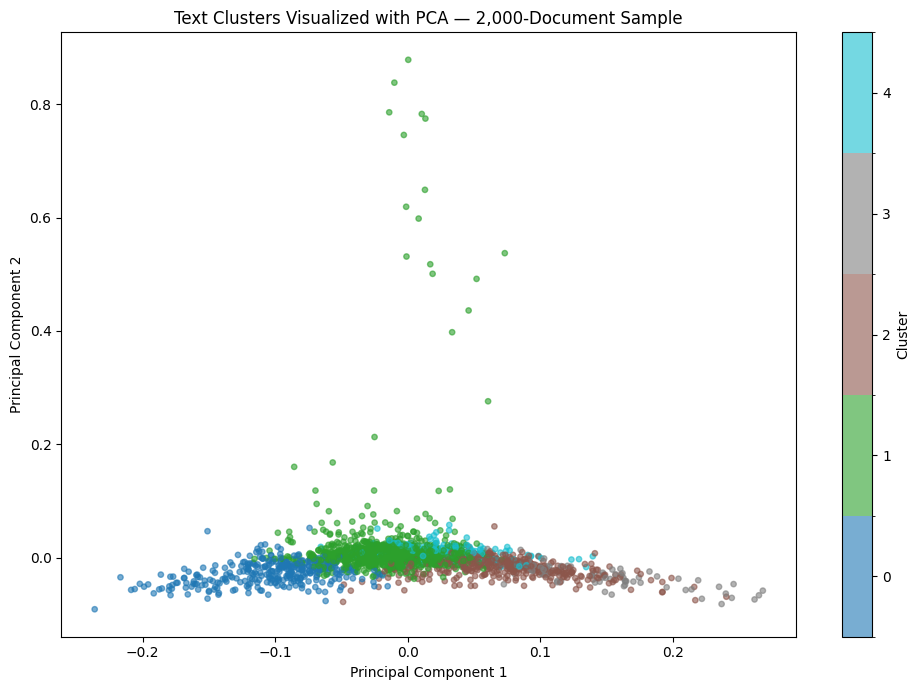

In [25]:
#Plot the five clusters
# Give each cluster a distinct color.
cmap = plt.get_cmap("tab10", kmeans.n_clusters)
boundaries = np.arange(-0.5, kmeans.n_clusters + 0.5, 1)
norm = BoundaryNorm(boundaries, cmap.N)

fig, ax = plt.subplots(figsize=(10, 7))

# Each point represents one selected document.
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=plot_clusters,
    cmap=cmap,
    norm=norm,
    s=15,
    alpha=0.6
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Text Clusters Visualized with PCA — 2,000-Document Sample")

# Show which color represents each cluster.
colorbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=range(kmeans.n_clusters)
)
colorbar.set_label("Cluster")

plt.tight_layout()
plt.show()

Each point represents one sampled document, and its color identifies its assigned cluster. The horizontal axis shows PC1, and the vertical axis shows PC2.

Cluster 0 (blue) is concentrated toward the left. Clusters 2 (brown) and 3 (gray) extend toward the right, with considerable overlap. Cluster 1 (green) is concentrated near the center but also has several points extending far upward. Cluster 4 (cyan) overlaps with other groups near the center.

Most documents form a narrow band around PC2 = 0. The upward extension of some green points shows variation within Cluster 1 along PC2, but it does not identify a specific topic by itself.

###Questions
###1. Are some clusters clearly separated?
There is partial separation, especially between the leftward concentration of Cluster 0 and the rightward extension of Cluster 3. However, the five clusters do not form fully separate groups.

###2. Are some clusters overlapping?
Yes. Several clusters overlap heavily near the center, particularly Cluster 4 with nearby groups. Clusters 2 and 3 also overlap on the right.

###3. What does this tell you about grouping text documents?
Text documents can share vocabulary across different topics, making topic boundaries difficult to separate. However, because this plot retains only 0.92% of the variation, the visible overlap alone cannot establish how well the clusters are separated in the original feature space. The important words and document examples remain necessary for interpreting the groups.

#Final Analysis

###1. What is TF-IDF and why is it useful for text data?
TF-IDF stands for Term Frequency–Inverse Document Frequency. It represents text numerically by weighting terms according to their occurrence within a document and across the collection. Terms common across many documents receive less emphasis than more distinctive terms.
I used TF-IDF to convert 11,014 documents into 10,000 numerical features, allowing K-Means to compare their word patterns.

###2. What value of K did you use?
I used K = 5, as instructed in the project. This produced five broad groups from a dataset containing 20 original categories. The category labels were not used during training.

###3. What topics did you find in the clusters?
The top words and sample documents suggested these themes:
- Cluster 0: Computer hardware and software.
- Cluster 1: Mixed general content, including advertisements and space-related discussions.
- Cluster 2: Mixed debate and technical content, including politics, religion, and encryption.
- Cluster 3: Religion, especially Christianity.
- Cluster 4: Sports, especially hockey and baseball.
These are descriptive labels based on the examined evidence, rather than confirmed topics for every document.

###4. Did the documents within each cluster appear similar?
Some did. Cluster 0’s examples consistently discussed computer problems, and Cluster 3’s examples discussed religious subjects. Cluster 4 also showed a strong sports theme, although one example discussed video games and electromagnetic noise. Clusters 1 and 2 contained more varied subjects.

###5. Were some clusters difficult to interpret?
Yes. Clusters 1 and 2 were the hardest to name clearly. Cluster 1’s top words were mostly general terms, and its examples covered unrelated subjects. Cluster 2 combined political, religious, and encryption discussions. These mixtures prevented a precise single-topic description.

###6. What did the PCA visualization show?
I applied PCA to a sample of 2,000 documents. The plot showed partial separation, with Cluster 0 concentrated toward the left and Clusters 2 and 3 extending toward the right. Several groups overlapped near the center.
The two components captured only 0.92% of the sample’s variation, so the visualization provides a very limited view. It cannot establish the quality of clustering in the original 10,000-feature space by itself.

###7. What is one limitation of using K-Means for text?
K-Means on TF-IDF features compares numerical word patterns without fully understanding context or meaning. Documents about different subjects can therefore enter the same cluster when they share vocabulary. The video-game document in the sports-related cluster illustrates a possible example of this limitation.